## 📌 STEP 1: PROBLEM DEFINITION

**Problem Statement:** Binary Text Classification

**Objective:** Classify text samples as:
- Class 0: Human-written text
- Class 1: AI-generated text

**Approach:** Supervised Machine Learning with TF-IDF features

## 📌 STEP 2: DATA EXPLORATION & PREPROCESSING

### Import Required Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text processing
import re
import string

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
import os

✅ Libraries imported successfully!


### Sub-step 2.1: Load Dataset

In [2]:
# Load the dataset
print("Loading dataset...")
df = pd.read_csv('AIvsHuman.csv')
print(f"✅ Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Total samples: {len(df):,}")

Loading dataset...
✅ Dataset loaded successfully!
Dataset shape: (44868, 5)
Total samples: 44,868


### Sub-step 2.2: Display Basic Information

In [3]:
# Display dataset info
print("Dataset Information:")
print("="*60)
df.info()
print("\n" + "="*60)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44868 entries, 0 to 44867
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           44868 non-null  object
 1   label          44868 non-null  int64 
 2   prompt_name    44868 non-null  object
 3   source         44868 non-null  object
 4   RDizzl3_seven  44868 non-null  bool  
dtypes: bool(1), int64(1), object(3)
memory usage: 1.4+ MB


Column Names:
['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven']


### Sub-step 2.3: Display First and Last Rows

In [4]:
# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

print("\nLast 5 rows of the dataset:")
display(df.tail())

First 5 rows of the dataset:


,text,label,prompt_name,source,RDizzl3_seven
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,False
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,False
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,False
3,Phones & Driving\n\nDrivers should not be able...,0,Phones and driving,persuade_corpus,False
4,Cell Phone Operation While Driving\n\nThe abil...,0,Phones and driving,persuade_corpus,False



Last 5 rows of the dataset:


,text,label,prompt_name,source,RDizzl3_seven
44863,"Dear Senator,\n\nI am writing to you today to ...",1,Does the electoral college work?,kingki19_palm,True
44864,"Dear Senator,\n\nI am writing to you today to ...",1,Does the electoral college work?,kingki19_palm,True
44865,"Dear Senator,\n\nI am writing to you today to ...",1,Does the electoral college work?,kingki19_palm,True
44866,"Dear Senator,\n\nI am writing to you today to ...",1,Does the electoral college work?,kingki19_palm,True
44867,"Dear Senator,\n\nI am writing to you today to ...",1,Does the electoral college work?,kingki19_palm,True


### Sub-step 2.4: Check for Missing Values

In [5]:
# Check for missing values
print("Missing Values Analysis:")
print("="*60)
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
})
print(missing_df)
print("="*60)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values Analysis:
               Missing Count  Percentage
text                       0         0.0
label                      0         0.0
prompt_name                0         0.0
source                     0         0.0
RDizzl3_seven              0         0.0

Total missing values: 0


### Sub-step 2.5: Check for Duplicate Entries

In [6]:
# Check for duplicates
print("Duplicate Analysis:")
print("="*60)
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count:,}")
print(f"Percentage of duplicates: {(duplicate_count/len(df)*100):.2f}%")

# Check duplicates in text column
text_duplicates = df['text'].duplicated().sum()
print(f"\nDuplicate text entries: {text_duplicates:,}")
print(f"Percentage: {(text_duplicates/len(df)*100):.2f}%")

Duplicate Analysis:
Number of duplicate rows: 0
Percentage of duplicates: 0.00%

Duplicate text entries: 0
Percentage: 0.00%


### Sub-step 2.6: Analyze Label Distribution

Label Distribution:
label
0    27371
1    17497
Name: count, dtype: int64

Percentage Distribution:
label
0    61.003388
1    38.996612
Name: proportion, dtype: float64


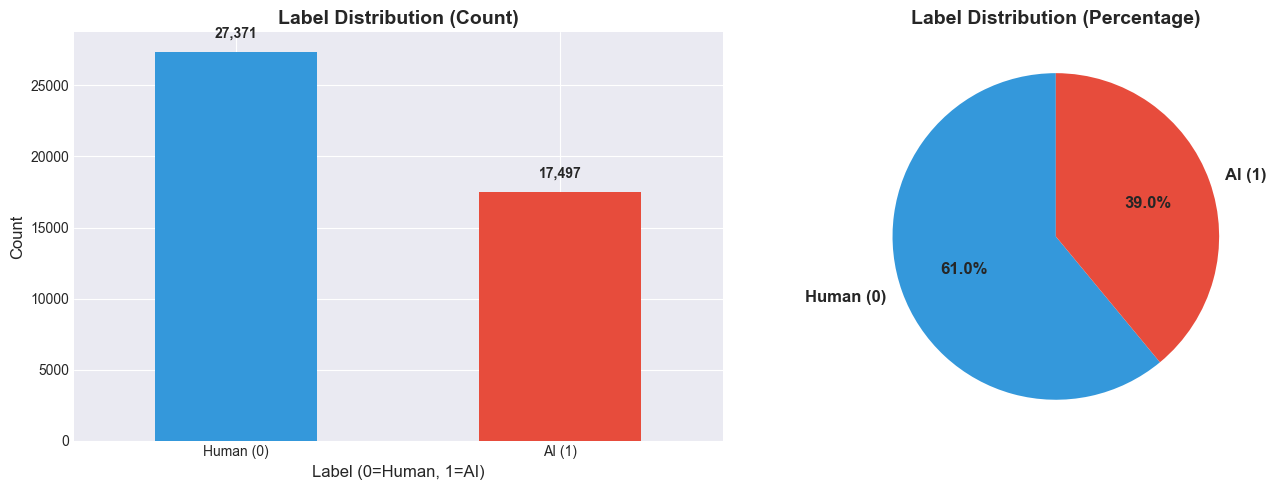


✅ Visualization saved to 'results/label_distribution.png'


In [7]:
# Label distribution
print("Label Distribution:")
print("="*60)
label_counts = df['label'].value_counts().sort_index()
print(label_counts)
print("\nPercentage Distribution:")
print(df['label'].value_counts(normalize=True).sort_index() * 100)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
label_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Label Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label (0=Human, 1=AI)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Human (0)', 'AI (1)'], rotation=0)
for i, v in enumerate(label_counts):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
colors = ['#3498db', '#e74c3c']
axes[1].pie(label_counts, labels=['Human (0)', 'AI (1)'], autopct='%1.1f%%', 
            startangle=90, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Label Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('results/label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved to 'results/label_distribution.png'")

### Sub-step 2.7: Text Length Analysis

In [8]:
# Calculate text statistics
print("Calculating text statistics...")
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df['avg_word_length'] = df['text'].astype(str).apply(lambda x: np.mean([len(word) for word in x.split()]))

print("\nText Statistics Summary:")
print("="*60)
print(df[['text_length', 'word_count', 'avg_word_length']].describe())

Calculating text statistics...

Text Statistics Summary:
        text_length    word_count  avg_word_length
count  44868.000000  44868.000000     44868.000000
mean    2216.222921    383.621334         4.750687
std      969.928064    164.926131         0.747028
min       48.000000      4.000000         3.167883
25%     1564.750000    274.000000         4.407833
50%     2044.000000    352.000000         4.686567
75%     2619.000000    451.000000         5.023799
max    18322.000000   1656.000000       126.250000


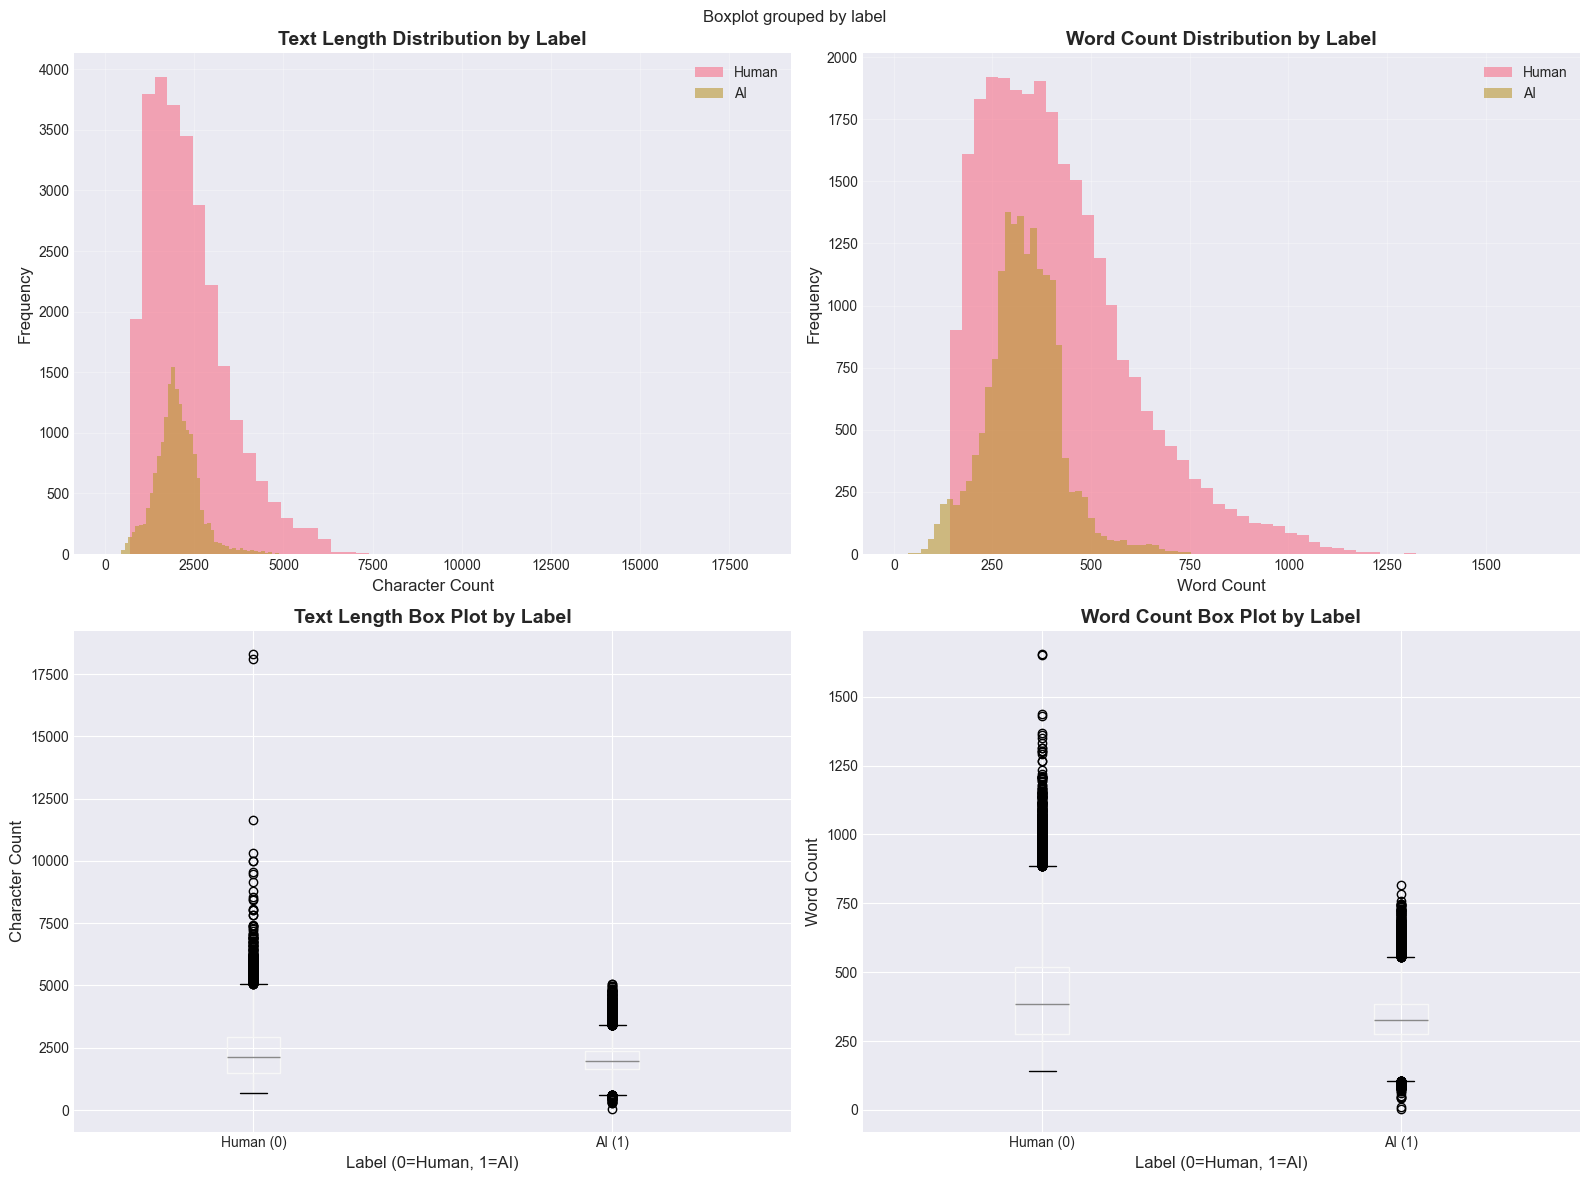

✅ Visualization saved to 'results/text_length_analysis.png'


In [9]:
# Visualize text length distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Character length by label
for label in [0, 1]:
    label_name = 'Human' if label == 0 else 'AI'
    data = df[df['label'] == label]['text_length']
    axes[0, 0].hist(data, bins=50, alpha=0.6, label=label_name)
axes[0, 0].set_title('Text Length Distribution by Label', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Character Count', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Word count by label
for label in [0, 1]:
    label_name = 'Human' if label == 0 else 'AI'
    data = df[df['label'] == label]['word_count']
    axes[0, 1].hist(data, bins=50, alpha=0.6, label=label_name)
axes[0, 1].set_title('Word Count Distribution by Label', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Word Count', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Box plot - text length
df.boxplot(column='text_length', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Text Length Box Plot by Label', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Label (0=Human, 1=AI)', fontsize=12)
axes[1, 0].set_ylabel('Character Count', fontsize=12)
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Human (0)', 'AI (1)'])

# Box plot - word count
df.boxplot(column='word_count', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Word Count Box Plot by Label', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Label (0=Human, 1=AI)', fontsize=12)
axes[1, 1].set_ylabel('Word Count', fontsize=12)
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Human (0)', 'AI (1)'])

plt.tight_layout()
plt.savefig('results/text_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved to 'results/text_length_analysis.png'")

### Sub-step 2.8: Statistical Summary by Label

In [10]:
# Group statistics by label
print("Text Statistics by Label:")
print("="*60)
print("\nHuman Text (Label = 0):")
print(df[df['label'] == 0][['text_length', 'word_count', 'avg_word_length']].describe())
print("\nAI Text (Label = 1):")
print(df[df['label'] == 1][['text_length', 'word_count', 'avg_word_length']].describe())

Text Statistics by Label:

Human Text (Label = 0):
        text_length    word_count  avg_word_length
count  27371.000000  27371.000000     27371.000000
mean    2348.503891    418.283146         4.531510
std     1124.489852    189.285918         0.329788
min      691.000000    143.000000         3.167883
25%     1499.500000    274.000000         4.302725
50%     2132.000000    383.000000         4.522569
75%     2929.000000    519.000000         4.753437
max    18322.000000   1656.000000         6.349693

AI Text (Label = 1):
        text_length    word_count  avg_word_length
count  17497.000000  17497.000000     17497.000000
mean    2009.292450    329.398983         5.093551
std      603.496414     94.256529         1.033548
min       48.000000      4.000000         3.674419
25%     1650.000000    274.000000         4.751534
50%     1973.000000    328.000000         5.064057
75%     2350.000000    386.000000         5.410390
max     5078.000000    818.000000       126.250000


### Sub-step 2.9: Sample Text Examples

In [11]:
# Display sample texts
print("Sample Human-Written Text (Label = 0):")
print("="*60)
sample_human = df[df['label'] == 0]['text'].iloc[0]
print(sample_human[:500] + "...\n")

print("\nSample AI-Generated Text (Label = 1):")
print("="*60)
if len(df[df['label'] == 1]) > 0:
    sample_ai = df[df['label'] == 1]['text'].iloc[0]
    print(sample_ai[:500] + "...")
else:
    print("No AI-generated samples found in dataset.")

Sample Human-Written Text (Label = 0):
Phones

Modern humans today are always on their phone. They are always on their phone more than 5 hours a day no stop .All they do is text back and forward and just have group Chats on social media. They even do it while driving. They are some really bad consequences when stuff happens when it comes to a phone. Some certain areas in the United States ban phones from class rooms just because of it.

When people have phones, they know about certain apps that they have .Apps like Facebook Twitter I...


Sample AI-Generated Text (Label = 1):
 In recent years, technology has had a profound impact on our daily lives and the world around us. From staying connected with loved ones to ordering food online through an app, technology has made our lives easier and more convenient. However, with great power comes great responsibility, and technology can also have negative consequences if used improperly.

One example of this is the spread of misinformation thr

### Sub-step 2.10: Generate Word Clouds

Generating word clouds...


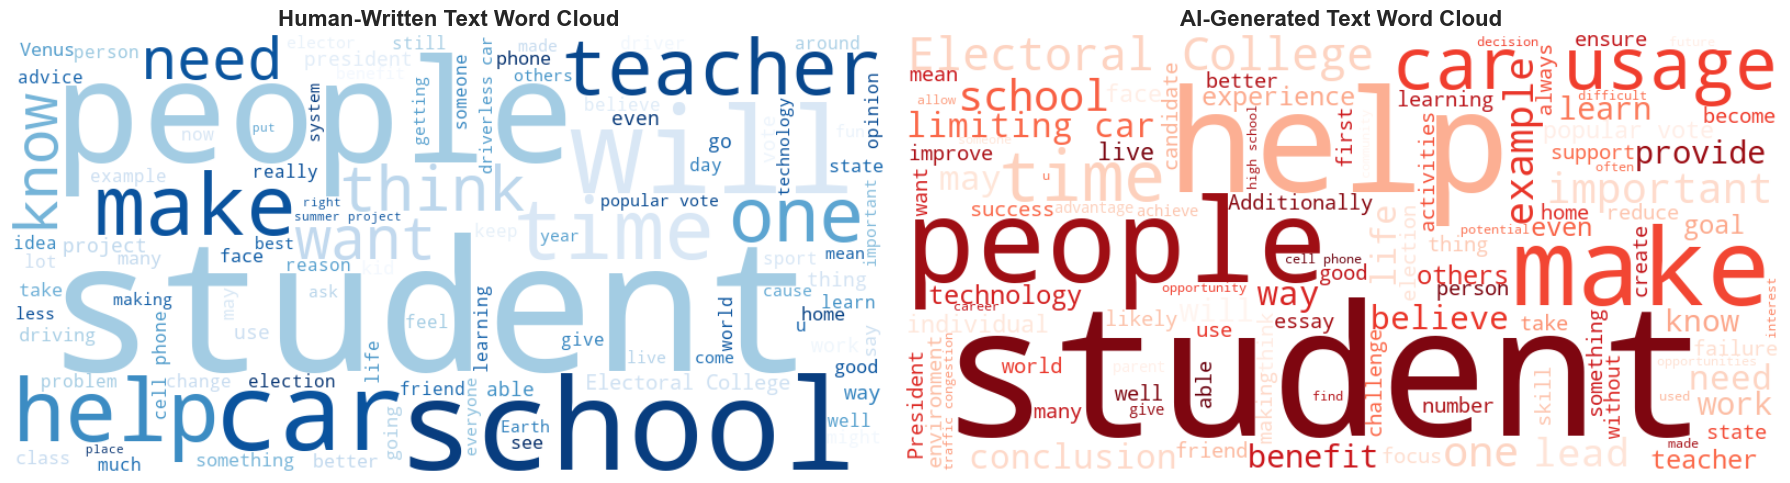

✅ Word clouds saved to 'results/wordclouds.png'


In [12]:
# Generate word clouds
print("Generating word clouds...")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Human text word cloud
human_text = ' '.join(df[df['label'] == 0]['text'].astype(str).sample(min(1000, len(df[df['label'] == 0]))))
wordcloud_human = WordCloud(width=800, height=400, background_color='white', 
                             colormap='Blues', max_words=100).generate(human_text)
axes[0].imshow(wordcloud_human, interpolation='bilinear')
axes[0].set_title('Human-Written Text Word Cloud', fontsize=16, fontweight='bold')
axes[0].axis('off')

# AI text word cloud
if len(df[df['label'] == 1]) > 0:
    ai_text = ' '.join(df[df['label'] == 1]['text'].astype(str).sample(min(1000, len(df[df['label'] == 1]))))
    wordcloud_ai = WordCloud(width=800, height=400, background_color='white', 
                             colormap='Reds', max_words=100).generate(ai_text)
    axes[1].imshow(wordcloud_ai, interpolation='bilinear')
    axes[1].set_title('AI-Generated Text Word Cloud', fontsize=16, fontweight='bold')
    axes[1].axis('off')
else:
    axes[1].text(0.5, 0.5, 'No AI samples available', 
                 ha='center', va='center', fontsize=16)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('results/wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Word clouds saved to 'results/wordclouds.png'")

### Sub-step 2.11: Remove Duplicates

In [13]:
# Remove duplicates
print("Removing duplicates...")
original_size = len(df)
df = df.drop_duplicates(subset=['text'], keep='first')
removed = original_size - len(df)
print(f"Removed {removed:,} duplicate entries")
print(f"New dataset size: {len(df):,}")

Removing duplicates...
Removed 0 duplicate entries
New dataset size: 44,868


### Sub-step 2.12: Handle Missing Values

In [14]:
# Handle missing values
print("Handling missing values...")
original_size = len(df)

# Remove rows with missing text or label
df = df.dropna(subset=['text', 'label'])

removed = original_size - len(df)
print(f"Removed {removed:,} rows with missing values")
print(f"Final dataset size: {len(df):,}")
print(f"\n✅ Data cleaning completed!")

Handling missing values...
Removed 0 rows with missing values
Final dataset size: 44,868

✅ Data cleaning completed!


### Sub-step 2.13-2.16: Text Preprocessing Function

In [15]:
# Define text cleaning function
def clean_text(text):
    """
    Clean and preprocess text data
    - Convert to lowercase
    - Remove URLs
    - Remove emails
    - Remove extra whitespaces
    - Remove special characters (keeping only letters and spaces)
    """
    # Convert to string
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("✅ Text cleaning function defined")

✅ Text cleaning function defined


### Sub-step 2.17: Apply Text Preprocessing

In [16]:
# Apply text cleaning
print("Applying text preprocessing...")
print("This may take a few minutes for large datasets...")

df['cleaned_text'] = df['text'].apply(clean_text)

# Remove empty texts after cleaning
df = df[df['cleaned_text'].str.len() > 0]

print(f"\n✅ Text preprocessing completed!")
print(f"Final dataset size after preprocessing: {len(df):,}")

Applying text preprocessing...
This may take a few minutes for large datasets...

✅ Text preprocessing completed!
Final dataset size after preprocessing: 44,868


### Sub-step 2.18: Verify Preprocessing Results

In [17]:
# Compare original vs cleaned text
print("Sample Text Comparison (Original vs Cleaned):")
print("="*80)
sample_idx = 0
print("\nOriginal Text:")
print(df['text'].iloc[sample_idx][:300])
print("\n" + "-"*80)
print("\nCleaned Text:")
print(df['cleaned_text'].iloc[sample_idx][:300])
print("\n" + "="*80)

# Display final dataset info
print("\nFinal Dataset Summary:")
print("="*60)
print(f"Total samples: {len(df):,}")
print(f"Features: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print("\n✅ Data preprocessing completed successfully!")

Sample Text Comparison (Original vs Cleaned):

Original Text:
Phones

Modern humans today are always on their phone. They are always on their phone more than 5 hours a day no stop .All they do is text back and forward and just have group Chats on social media. They even do it while driving. They are some really bad consequences when stuff happens when it comes

--------------------------------------------------------------------------------

Cleaned Text:
phones modern humans today are always on their phone they are always on their phone more than hours a day no stop all they do is text back and forward and just have group chats on social media they even do it while driving they are some really bad consequences when stuff happens when it comes to a p


Final Dataset Summary:
Total samples: 44,868
Features: ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven', 'text_length', 'word_count', 'avg_word_length', 'cleaned_text']

Label distribution:
label
0    27371
1    17497
Name: cou

## 📌 STEP 3: FEATURE EXTRACTION (TF-IDF)

### Import Machine Learning Libraries

In [18]:
# Import ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve)

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                              AdaBoostClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# XGBoost and LightGBM
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False
    print("⚠️ XGBoost not available, will skip")

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except:
    lgbm_available = False
    print("⚠️ LightGBM not available, will skip")

# Model persistence
import joblib
import json
from datetime import datetime
import time

print("✅ Machine Learning libraries imported successfully!")

⚠️ LightGBM not available, will skip
✅ Machine Learning libraries imported successfully!


### Sub-step 3.1-3.2: Configure TF-IDF Vectorizer

In [19]:
# Sub-step 3.1-3.2: Configure TF-IDF Vectorizer
print("Configuring TF-IDF Vectorizer...")
print("="*60)

# Initialize TF-IDF Vectorizer with optimized parameters
tfidf = TfidfVectorizer(
    max_features=5000,        # Limit to top 5000 features
    ngram_range=(1, 2),       # Use unigrams and bigrams
    min_df=2,                 # Minimum document frequency
    max_df=0.95,              # Maximum document frequency
    strip_accents='unicode',
    lowercase=True,
    token_pattern=r'\b[a-zA-Z]{3,}\b',  # Only words with 3+ letters
    stop_words='english'      # Remove English stop words
)

print("✅ TF-IDF Vectorizer configured with parameters:")
print(f"   - Max features: 5000")
print(f"   - N-gram range: (1, 2)")
print(f"   - Min document frequency: 2")
print(f"   - Max document frequency: 0.95")
print(f"   - Stop words: English")

Configuring TF-IDF Vectorizer...
✅ TF-IDF Vectorizer configured with parameters:
   - Max features: 5000
   - N-gram range: (1, 2)
   - Min document frequency: 2
   - Max document frequency: 0.95
   - Stop words: English


### Sub-step 3.9: Train-Test Split

In [20]:
# Sub-step 3.9: Split data into train and test sets
print("\nSub-step 3.9: Splitting data into train and test sets...")
print("="*60)

# Prepare X and y
X = df['cleaned_text']
y = df['label']

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"✅ Data split completed!")
print(f"\nTraining set size: {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test set size: {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)")
print(f"\nTraining label distribution:")
print(y_train.value_counts())
print(f"\nTest label distribution:")
print(y_test.value_counts())


Sub-step 3.9: Splitting data into train and test sets...
✅ Data split completed!

Training set size: 35,894 (80.0%)
Test set size: 8,974 (20.0%)

Training label distribution:
label
0    21897
1    13997
Name: count, dtype: int64

Test label distribution:
label
0    5474
1    3500
Name: count, dtype: int64


### Sub-step 3.3-3.4: Fit and Transform TF-IDF

In [21]:
# Sub-step 3.3-3.4: Fit TF-IDF and transform data
print("\nSub-step 3.3-3.4: Fitting TF-IDF on training data...")
print("This may take a few minutes...")
print("="*60)

start_time = time.time()

# Fit on training data
tfidf.fit(X_train)

# Transform both train and test
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

elapsed_time = time.time() - start_time

print(f"✅ TF-IDF transformation completed in {elapsed_time:.2f} seconds!")
print(f"\nTraining feature matrix shape: {X_train_tfidf.shape}")
print(f"Test feature matrix shape: {X_test_tfidf.shape}")
print(f"Total features extracted: {X_train_tfidf.shape[1]:,}")


Sub-step 3.3-3.4: Fitting TF-IDF on training data...
This may take a few minutes...
✅ TF-IDF transformation completed in 36.10 seconds!

Training feature matrix shape: (35894, 5000)
Test feature matrix shape: (8974, 5000)
Total features extracted: 5,000


### Sub-step 3.5-3.7: Analyze TF-IDF Features


Sub-step 3.5-3.7: Analyzing TF-IDF features...

Top 20 TF-IDF Features:
------------------------------------------------------------
students             : 0.064230
school               : 0.039651
car                  : 0.037419
people               : 0.036896
cars                 : 0.032119
electoral            : 0.030151
like                 : 0.029887
help                 : 0.026235
venus                : 0.025808
college              : 0.025563
electoral college    : 0.024430
time                 : 0.023164
student              : 0.023028
vote                 : 0.022156
think                : 0.022032
make                 : 0.021571
just                 : 0.021543
phones               : 0.019174
work                 : 0.019120
driving              : 0.018332


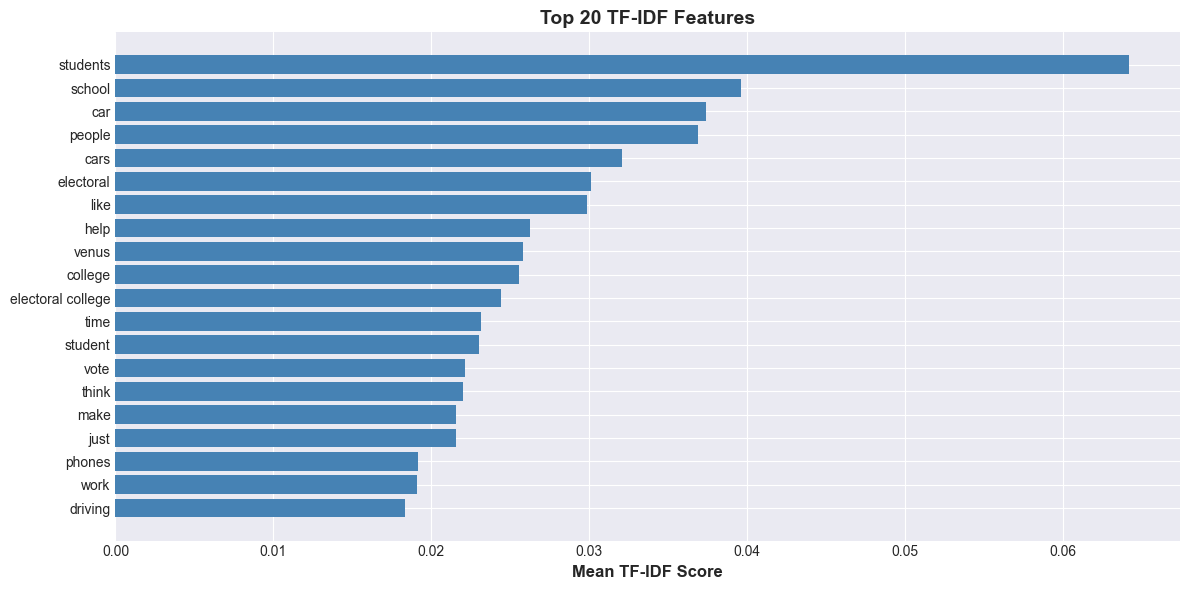


✅ Feature visualization saved to 'results/top_tfidf_features.png'


In [22]:
# Sub-step 3.5-3.7: Analyze TF-IDF features
print("\nSub-step 3.5-3.7: Analyzing TF-IDF features...")
print("="*60)

# Get feature names
feature_names = tfidf.get_feature_names_out()

# Calculate feature importance (mean TF-IDF scores)
feature_importance = np.array(X_train_tfidf.mean(axis=0)).flatten()
top_indices = feature_importance.argsort()[-20:][::-1]

print("\nTop 20 TF-IDF Features:")
print("-"*60)
for idx in top_indices:
    print(f"{feature_names[idx]:20s} : {feature_importance[idx]:.6f}")

# Visualize top features
plt.figure(figsize=(12, 6))
top_features = [feature_names[i] for i in top_indices]
top_scores = [feature_importance[i] for i in top_indices]
plt.barh(range(len(top_features)), top_scores, color='steelblue')
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Mean TF-IDF Score', fontsize=12, fontweight='bold')
plt.title('Top 20 TF-IDF Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('results/top_tfidf_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Feature visualization saved to 'results/top_tfidf_features.png'")

### Sub-step 3.8: Save TF-IDF Vectorizer

In [23]:
# Sub-step 3.8: Save TF-IDF vectorizer
print("\nSub-step 3.8: Saving TF-IDF vectorizer...")
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')
print("✅ TF-IDF vectorizer saved to 'models/tfidf_vectorizer.pkl'")
print("\n" + "="*60)
print("✅ STEP 3: Feature Extraction completed successfully!")
print("="*60)


Sub-step 3.8: Saving TF-IDF vectorizer...
✅ TF-IDF vectorizer saved to 'models/tfidf_vectorizer.pkl'

✅ STEP 3: Feature Extraction completed successfully!


## 📌 STEP 4: TRAIN 12 MACHINE LEARNING ALGORITHMS

### Define Evaluation Function

In [24]:
# Sub-step 4.1-4.2: Define evaluation metrics function
def evaluate_model(name, model, X_train, X_test, y_train, y_test, training_time):
    """
    Evaluate a trained model and return performance metrics
    """
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # ROC-AUC (if probability predictions available)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    results = {
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Training Time (s)': training_time
    }
    
    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    if roc_auc:
        print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"Training Time: {training_time:.2f}s")
    
    return results

print("✅ Evaluation function defined")

✅ Evaluation function defined


### Train All Models

In [25]:
# Sub-step 4.3-4.15: Train all models
print("\n" + "="*60)
print("TRAINING 12 MACHINE LEARNING MODELS")
print("="*60)
print("\nThis will take several minutes...")

# Dictionary to store all models and results
models_dict = {}
results_list = []

# Model 1: Logistic Regression
print("\n[1/12] Training Logistic Regression...")
start = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_tfidf, y_train)
lr_time = time.time() - start
models_dict['Logistic Regression'] = lr
results_list.append(evaluate_model('Logistic Regression', lr, X_train_tfidf, X_test_tfidf, y_train, y_test, lr_time))

# Model 2: Random Forest
print("\n[2/12] Training Random Forest...")
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
rf_time = time.time() - start
models_dict['Random Forest'] = rf
results_list.append(evaluate_model('Random Forest', rf, X_train_tfidf, X_test_tfidf, y_train, y_test, rf_time))

# Model 3: Gradient Boosting
print("\n[3/12] Training Gradient Boosting...")
start = time.time()
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_tfidf, y_train)
gb_time = time.time() - start
models_dict['Gradient Boosting'] = gb
results_list.append(evaluate_model('Gradient Boosting', gb, X_train_tfidf, X_test_tfidf, y_train, y_test, gb_time))

# Model 4: XGBoost (if available)
if xgb_available:
    print("\n[4/12] Training XGBoost...")
    start = time.time()
    xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
    xgb_model.fit(X_train_tfidf, y_train)
    xgb_time = time.time() - start
    models_dict['XGBoost'] = xgb_model
    results_list.append(evaluate_model('XGBoost', xgb_model, X_train_tfidf, X_test_tfidf, y_train, y_test, xgb_time))
else:
    print("\n[4/12] XGBoost not available, skipping...")

# Model 5: LightGBM (if available)
if lgbm_available:
    print("\n[5/12] Training LightGBM...")
    start = time.time()
    lgbm_model = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
    lgbm_model.fit(X_train_tfidf, y_train)
    lgbm_time = time.time() - start
    models_dict['LightGBM'] = lgbm_model
    results_list.append(evaluate_model('LightGBM', lgbm_model, X_train_tfidf, X_test_tfidf, y_train, y_test, lgbm_time))
else:
    print("\n[5/12] LightGBM not available, skipping...")

# Model 6: Linear SVM
print("\n[6/12] Training Linear SVM...")
start = time.time()
linear_svm = LinearSVC(max_iter=1000, random_state=42)
linear_svm.fit(X_train_tfidf, y_train)
linear_svm_time = time.time() - start
models_dict['Linear SVM'] = linear_svm
# Note: LinearSVC doesn't have predict_proba, so we handle it differently
y_pred = linear_svm.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
results_list.append({
    'Model': 'Linear SVM',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': None,
    'Training Time (s)': linear_svm_time
})
print(f"\n{'='*60}")
print(f"Model: Linear SVM")
print(f"{'='*60}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {linear_svm_time:.2f}s")

# Model 7: RBF SVM (with smaller sample for speed)
print("\n[7/12] Training RBF SVM (on sample)...")
sample_size = min(10000, len(X_train_tfidf.toarray()))
sample_indices = np.random.choice(X_train_tfidf.shape[0], sample_size, replace=False)
X_train_sample = X_train_tfidf[sample_indices]
y_train_sample = y_train.iloc[sample_indices]
start = time.time()
rbf_svm = SVC(kernel='rbf', probability=True, random_state=42)
rbf_svm.fit(X_train_sample, y_train_sample)
rbf_svm_time = time.time() - start
models_dict['RBF SVM'] = rbf_svm
results_list.append(evaluate_model('RBF SVM', rbf_svm, X_train_sample, X_test_tfidf, y_train_sample, y_test, rbf_svm_time))

# Model 8: Naive Bayes
print("\n[8/12] Training Naive Bayes...")
start = time.time()
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_time = time.time() - start
models_dict['Naive Bayes'] = nb
results_list.append(evaluate_model('Naive Bayes', nb, X_train_tfidf, X_test_tfidf, y_train, y_test, nb_time))

# Model 9: K-Nearest Neighbors (on sample for speed)
print("\n[9/12] Training K-Nearest Neighbors (on sample)...")
start = time.time()
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_sample, y_train_sample)
knn_time = time.time() - start
models_dict['K-Nearest Neighbors'] = knn
results_list.append(evaluate_model('K-Nearest Neighbors', knn, X_train_sample, X_test_tfidf, y_train_sample, y_test, knn_time))

# Model 10: Decision Tree
print("\n[10/12] Training Decision Tree...")
start = time.time()
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_tfidf, y_train)
dt_time = time.time() - start
models_dict['Decision Tree'] = dt
results_list.append(evaluate_model('Decision Tree', dt, X_train_tfidf, X_test_tfidf, y_train, y_test, dt_time))

# Model 11: AdaBoost
print("\n[11/12] Training AdaBoost...")
start = time.time()
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train_tfidf, y_train)
ada_time = time.time() - start
models_dict['AdaBoost'] = ada
results_list.append(evaluate_model('AdaBoost', ada, X_train_tfidf, X_test_tfidf, y_train, y_test, ada_time))

# Model 12: Extra Trees
print("\n[12/12] Training Extra Trees...")
start = time.time()
et = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
et.fit(X_train_tfidf, y_train)
et_time = time.time() - start
models_dict['Extra Trees'] = et
results_list.append(evaluate_model('Extra Trees', et, X_train_tfidf, X_test_tfidf, y_train, y_test, et_time))

print("\n" + "="*60)
print("✅ ALL MODELS TRAINED SUCCESSFULLY!")
print("="*60)


TRAINING 12 MACHINE LEARNING MODELS

This will take several minutes...

[1/12] Training Logistic Regression...

Model: Logistic Regression
Accuracy:  0.9896
Precision: 0.9897
Recall:    0.9896
F1-Score:  0.9896
ROC-AUC:   0.9988
Training Time: 5.01s

[2/12] Training Random Forest...

Model: Random Forest
Accuracy:  0.9848
Precision: 0.9850
Recall:    0.9848
F1-Score:  0.9848
ROC-AUC:   0.9974
Training Time: 22.81s

[3/12] Training Gradient Boosting...

Model: Gradient Boosting
Accuracy:  0.9614
Precision: 0.9622
Recall:    0.9614
F1-Score:  0.9612
ROC-AUC:   0.9921
Training Time: 192.63s

[4/12] Training XGBoost...

Model: XGBoost
Accuracy:  0.9896
Precision: 0.9897
Recall:    0.9896
F1-Score:  0.9896
ROC-AUC:   0.9990
Training Time: 55.98s

[5/12] LightGBM not available, skipping...

[6/12] Training Linear SVM...

Model: Linear SVM
Accuracy:  0.9930
Precision: 0.9930
Recall:    0.9930
F1-Score:  0.9930
Training Time: 0.71s

[7/12] Training RBF SVM (on sample)...

Model: RBF SVM
Accur

## 📌 STEP 5: MODEL EVALUATION & OPTIMIZATION

### Sub-step 5.1-5.6: Create Model Comparison Table

In [26]:
# Sub-step 5.1-5.6: Create comprehensive comparison table
print("\nCreating model comparison table...")
print("="*60)

# Create DataFrame from results
results_df = pd.DataFrame(results_list)

# Sort by F1-Score
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\nMODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv('models/model_comparison.csv', index=False)
print("\n✅ Results saved to 'models/model_comparison.csv'")


Creating model comparison table...

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Training Time (s)
         Linear SVM  0.992980   0.992996 0.992980  0.992974      NaN           0.712336
            RBF SVM  0.991977   0.992040 0.991977  0.991964 0.998737         205.066278
            XGBoost  0.989637   0.989658 0.989637  0.989626 0.998958          55.982071
Logistic Regression  0.989637   0.989705 0.989637  0.989619 0.998764           5.007693
        Extra Trees  0.989080   0.989160 0.989080  0.989060 0.998278          26.916990
      Random Forest  0.984845   0.984952 0.984845  0.984812 0.997450          22.807571
K-Nearest Neighbors  0.969690   0.969668 0.969690  0.969657 0.989724           0.007838
  Gradient Boosting  0.961444   0.962174 0.961444  0.961201 0.992097         192.625054
        Naive Bayes  0.957990   0.958313 0.957990  0.957789 0.991285           0.025156
      Decision Tree  0.921440   0.921469 0.921440  0.9

### Sub-step 5.7-5.9: Visualize Model Comparison

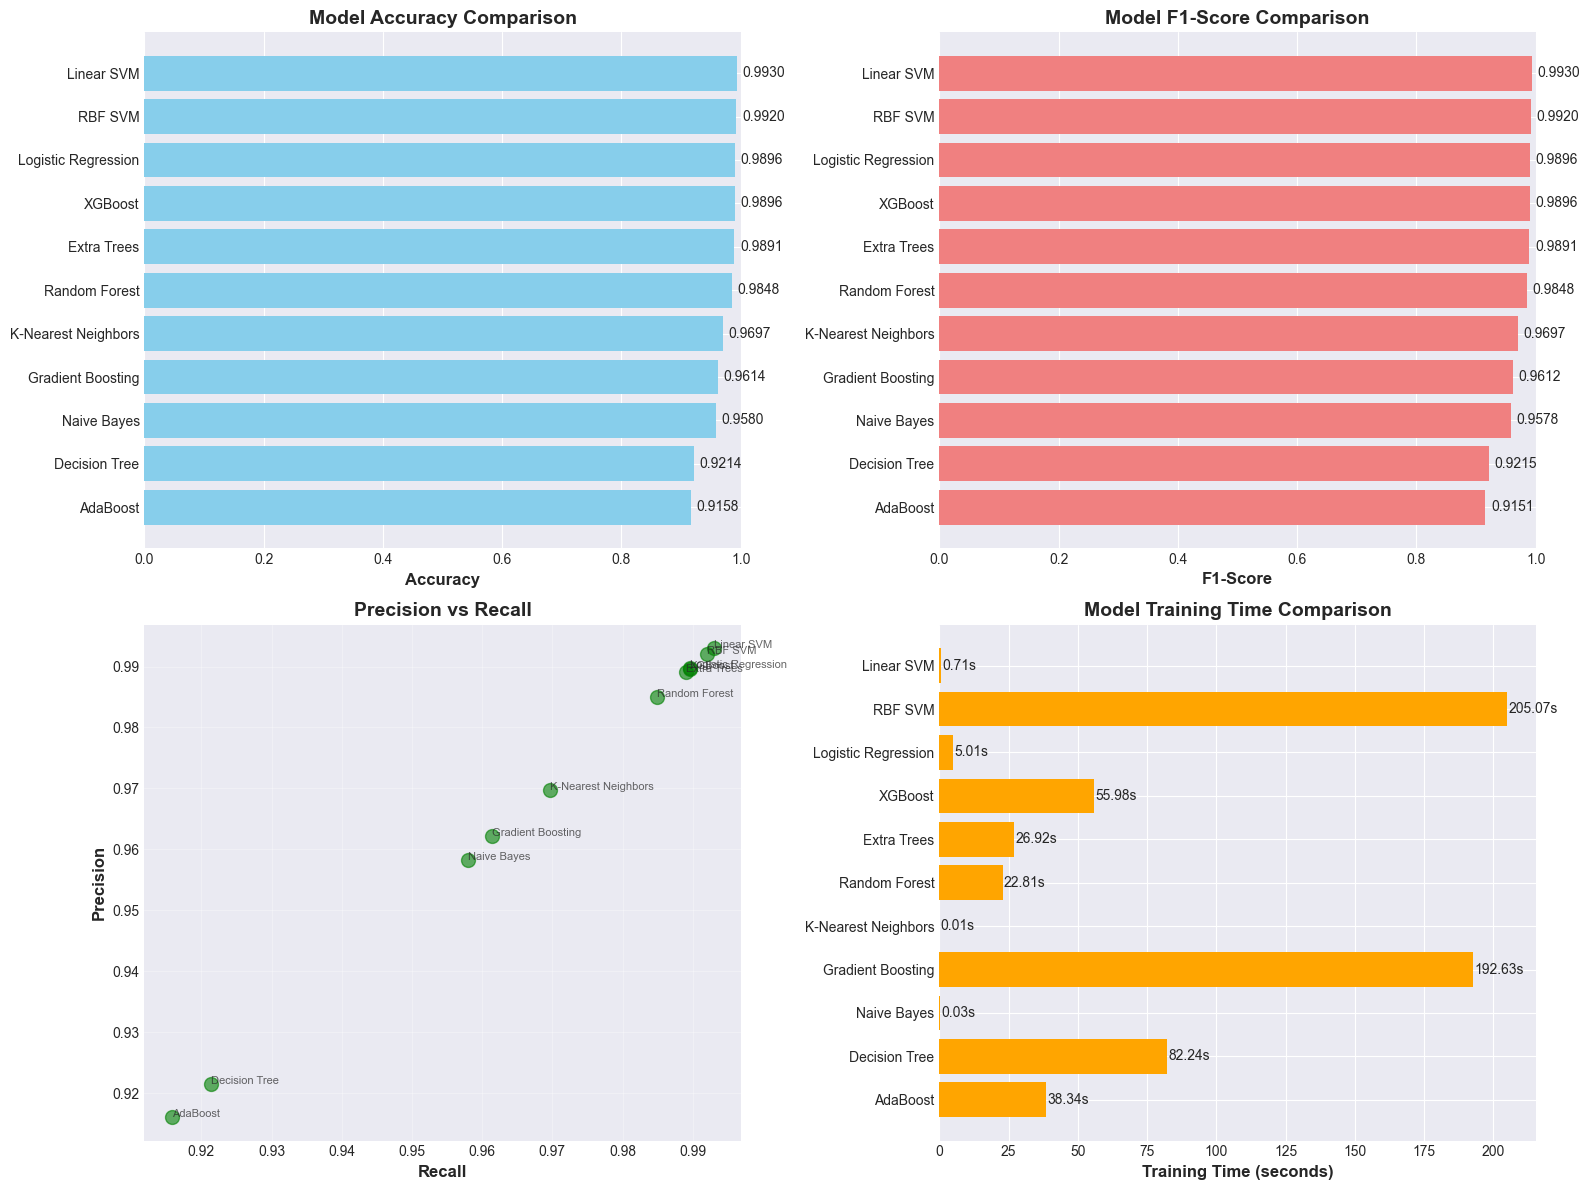

✅ Visualizations saved to 'results/model_comparison.png'


In [27]:
# Sub-step 5.7-5.9: Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sort by accuracy for consistent visualization
plot_df = results_df.sort_values('Accuracy', ascending=True)

# Plot 1: Accuracy comparison
axes[0, 0].barh(plot_df['Model'], plot_df['Accuracy'], color='skyblue')
axes[0, 0].set_xlabel('Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim([0, 1])
for i, v in enumerate(plot_df['Accuracy']):
    axes[0, 0].text(v + 0.01, i, f'{v:.4f}', va='center')

# Plot 2: F1-Score comparison
axes[0, 1].barh(plot_df['Model'], plot_df['F1-Score'], color='lightcoral')
axes[0, 1].set_xlabel('F1-Score', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim([0, 1])
for i, v in enumerate(plot_df['F1-Score']):
    axes[0, 1].text(v + 0.01, i, f'{v:.4f}', va='center')

# Plot 3: Precision vs Recall
axes[1, 0].scatter(plot_df['Recall'], plot_df['Precision'], s=100, alpha=0.6, c='green')
for i, model in enumerate(plot_df['Model']):
    axes[1, 0].annotate(model, (plot_df['Recall'].iloc[i], plot_df['Precision'].iloc[i]), 
                        fontsize=8, alpha=0.7)
axes[1, 0].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Training Time comparison
axes[1, 1].barh(plot_df['Model'], plot_df['Training Time (s)'], color='orange')
axes[1, 1].set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Model Training Time Comparison', fontsize=14, fontweight='bold')
for i, v in enumerate(plot_df['Training Time (s)']):
    axes[1, 1].text(v + 0.5, i, f'{v:.2f}s', va='center')

plt.tight_layout()
plt.savefig('results/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualizations saved to 'results/model_comparison.png'")

### Sub-step 5.10: Identify Best Model

In [28]:
# Sub-step 5.10: Identify the best model
print("\n" + "="*60)
print("BEST MODEL IDENTIFICATION")
print("="*60)

best_model_row = results_df.iloc[0]
best_model_name = best_model_row['Model']
best_model = models_dict[best_model_name]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"\nPerformance Metrics:")
print(f"  - Accuracy:  {best_model_row['Accuracy']:.4f}")
print(f"  - Precision: {best_model_row['Precision']:.4f}")
print(f"  - Recall:    {best_model_row['Recall']:.4f}")
print(f"  - F1-Score:  {best_model_row['F1-Score']:.4f}")
if best_model_row['ROC-AUC']:
    print(f"  - ROC-AUC:   {best_model_row['ROC-AUC']:.4f}")
print(f"  - Training Time: {best_model_row['Training Time (s)']:.2f}s")

print("\n" + "="*60)


BEST MODEL IDENTIFICATION

🏆 BEST MODEL: Linear SVM

Performance Metrics:
  - Accuracy:  0.9930
  - Precision: 0.9930
  - Recall:    0.9930
  - F1-Score:  0.9930
  - ROC-AUC:   nan
  - Training Time: 0.71s



### Sub-step 5.11-5.12: Detailed Evaluation of Best Model


Detailed Classification Report for Best Model:
              precision    recall  f1-score   support

   Human (0)       0.99      1.00      0.99      5474
      AI (1)       1.00      0.99      0.99      3500

    accuracy                           0.99      8974
   macro avg       0.99      0.99      0.99      8974
weighted avg       0.99      0.99      0.99      8974



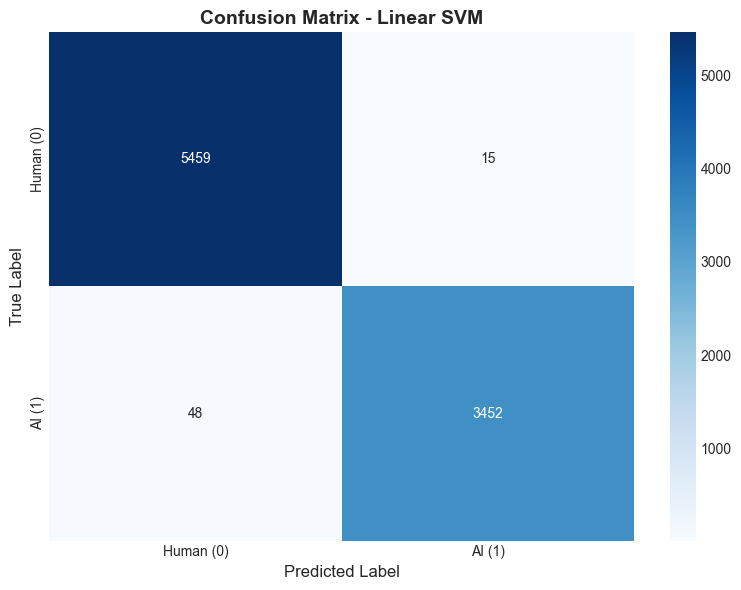


✅ Confusion matrix saved


In [29]:
# Sub-step 5.11-5.12: Generate detailed classification report
print("\nDetailed Classification Report for Best Model:")
print("="*60)

# Get predictions
y_pred_best = best_model.predict(X_test_tfidf)

# Classification report
print(classification_report(y_test, y_pred_best, target_names=['Human (0)', 'AI (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Human (0)', 'AI (1)'],
            yticklabels=['Human (0)', 'AI (1)'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(f'results/confusion_matrix_{best_model_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Confusion matrix saved")

### Sub-step 5.13-5.19: Hyperparameter Optimization

In [30]:
# Sub-step 5.13-5.19: Hyperparameter tuning for best model
print("\n" + "="*60)
print("HYPERPARAMETER OPTIMIZATION")
print("="*60)
print(f"\nOptimizing {best_model_name}...")

# Define parameter grid based on best model type
if best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear']
    }
    base_model = LogisticRegression(max_iter=1000, random_state=42)
    
elif best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    
elif best_model_name == 'Naive Bayes':
    param_grid = {
        'alpha': [0.1, 0.5, 1.0, 2.0]
    }
    base_model = MultinomialNB()
    
elif best_model_name == 'Extra Trees':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
    base_model = ExtraTreesClassifier(random_state=42, n_jobs=-1)
    
else:
    # Default: use existing best model
    print(f"Using existing {best_model_name} without additional tuning")
    optimized_model = best_model
    param_grid = None

if param_grid:
    print(f"\nParameter grid: {param_grid}")
    print("\nPerforming Grid Search (this may take several minutes)...")
    
    # Perform grid search
    grid_search = GridSearchCV(
        base_model, 
        param_grid, 
        cv=3, 
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train_tfidf, y_train)
    
    print(f"\n✅ Grid Search completed!")
    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")
    
    # Use optimized model
    optimized_model = grid_search.best_estimator_
else:
    optimized_model = best_model

print("\n" + "="*60)


HYPERPARAMETER OPTIMIZATION

Optimizing Linear SVM...
Using existing Linear SVM without additional tuning



### Sub-step 5.20-5.22: Cross-Validation & Final Evaluation

In [31]:
# Sub-step 5.20-5.22: Perform cross-validation
print("\nPerforming 5-Fold Cross-Validation...")
cv_scores = cross_val_score(optimized_model, X_train_tfidf, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)

print(f"\nCross-Validation F1-Scores: {cv_scores}")
print(f"Mean CV F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Final training on full training set
print("\nFinal training on full training set...")
start_time = time.time()
optimized_model.fit(X_train_tfidf, y_train)
final_training_time = time.time() - start_time

# Final evaluation
y_pred_final = optimized_model.predict(X_test_tfidf)
final_accuracy = accuracy_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final, average='weighted')

print(f"\n" + "="*60)
print("FINAL OPTIMIZED MODEL PERFORMANCE")
print("="*60)
print(f"Model: {best_model_name} (Optimized)")
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"F1-Score:  {final_f1:.4f}")
print(f"Training Time: {final_training_time:.2f}s")
print(f"\n✅ STEP 5: Model Evaluation & Optimization completed!")
print("="*60)


Performing 5-Fold Cross-Validation...

Cross-Validation F1-Scores: [0.99414617 0.9949821  0.99246911 0.9942846  0.99400615]
Mean CV F1-Score: 0.9940 (+/- 0.0017)

Final training on full training set...

FINAL OPTIMIZED MODEL PERFORMANCE
Model: Linear SVM (Optimized)
Accuracy:  0.9930
F1-Score:  0.9930
Training Time: 0.64s

✅ STEP 5: Model Evaluation & Optimization completed!


## 📌 STEP 6: SAVE BEST MODEL

### Sub-step 6.1-6.8: Save Model, Vectorizer, and Metadata

In [32]:
# Sub-step 6.1-6.8: Save all necessary files
print("\n" + "="*60)
print("SAVING BEST MODEL AND COMPONENTS")
print("="*60)

# Save the optimized model
model_filename = 'models/best_model.pkl'
joblib.dump(optimized_model, model_filename)
print(f"\n✅ Model saved: {model_filename}")

# TF-IDF vectorizer already saved earlier, verify it exists
vectorizer_filename = 'models/tfidf_vectorizer.pkl'
if not os.path.exists(vectorizer_filename):
    joblib.dump(tfidf, vectorizer_filename)
    print(f"✅ Vectorizer saved: {vectorizer_filename}")
else:
    print(f"✅ Vectorizer exists: {vectorizer_filename}")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'model_type': str(type(optimized_model).__name__),
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset_size': len(df),
    'training_size': len(X_train),
    'test_size': len(X_test),
    'features': X_train_tfidf.shape[1],
    'performance': {
        'accuracy': float(final_accuracy),
        'f1_score': float(final_f1),
        'cv_mean_f1': float(cv_scores.mean()),
        'cv_std_f1': float(cv_scores.std())
    },
    'parameters': str(optimized_model.get_params()) if hasattr(optimized_model, 'get_params') else 'N/A',
    'training_time_seconds': float(final_training_time)
}

metadata_filename = 'models/model_metadata.json'
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"✅ Metadata saved: {metadata_filename}")

# Test loading the saved model
print("\nVerifying saved model...")
loaded_model = joblib.load(model_filename)
loaded_vectorizer = joblib.load(vectorizer_filename)
print("✅ Model and vectorizer loaded successfully!")

# Test prediction with loaded model
sample_text = df['cleaned_text'].iloc[0]
sample_vectorized = loaded_vectorizer.transform([sample_text])
sample_prediction = loaded_model.predict(sample_vectorized)
print(f"\nTest prediction with loaded model: {sample_prediction[0]}")
print(f"Actual label: {df['label'].iloc[0]}")

print("\n" + "="*60)
print("✅ STEP 6: Model Saving completed successfully!")
print("="*60)

# Display all saved files
print("\nSaved Files:")
print(f"  1. {model_filename}")
print(f"  2. {vectorizer_filename}")
print(f"  3. {metadata_filename}")
print(f"  4. models/model_comparison.csv")


SAVING BEST MODEL AND COMPONENTS

✅ Model saved: models/best_model.pkl
✅ Vectorizer exists: models/tfidf_vectorizer.pkl
✅ Metadata saved: models/model_metadata.json

Verifying saved model...
✅ Model and vectorizer loaded successfully!

Test prediction with loaded model: 0
Actual label: 0

✅ STEP 6: Model Saving completed successfully!

Saved Files:
  1. models/best_model.pkl
  2. models/tfidf_vectorizer.pkl
  3. models/model_metadata.json
  4. models/model_comparison.csv


## 📌 STEP 7: DEPLOYMENT PREPARATION

### Create Deployment Files

All deployment files have been created in the `deployment/` folder:
- `app.py` - Flask web application
- `templates/index.html` - Web interface
- `static/style.css` - Styling
- `requirements.txt` - Dependencies
- `DEPLOYMENT_GUIDE.md` - Step-by-step deployment instructions

The deployment files are ready for PythonAnywhere or any other cloud platform!

In [33]:
# Display project summary
import os

print("\n" + "="*60)
print("PROJECT COMPLETION SUMMARY")
print("="*60)

print("\n✅ ALL STEPS COMPLETED SUCCESSFULLY!")
print("\n📁 Project Structure:")
print("="*60)

def print_tree(directory, prefix="", max_depth=3, current_depth=0):
    if current_depth >= max_depth:
        return
    
    try:
        items = sorted(os.listdir(directory))
        dirs = [item for item in items if os.path.isdir(os.path.join(directory, item)) and not item.startswith('.')]
        files = [item for item in items if os.path.isfile(os.path.join(directory, item)) and not item.startswith('.')]
        
        for i, d in enumerate(dirs):
            is_last = (i == len(dirs) - 1 and len(files) == 0)
            print(f"{prefix}{'└── ' if is_last else '├── '}{d}/")
            new_prefix = prefix + ("    " if is_last else "│   ")
            print_tree(os.path.join(directory, d), new_prefix, max_depth, current_depth + 1)
        
        for i, f in enumerate(files):
            is_last = (i == len(files) - 1)
            print(f"{prefix}{'└── ' if is_last else '├── '}{f}")
    except PermissionError:
        pass

print_tree(".")

print("\n" + "="*60)
print("📊 MODEL PERFORMANCE")
print("="*60)
print(f"Best Model: {best_model_name}")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"F1-Score: {final_f1:.4f}")

print("\n" + "="*60)
print("🚀 NEXT STEPS")
print("="*60)
print("1. Review the results/ folder for all visualizations")
print("2. Check models/ folder for saved model and metadata")
print("3. Go to deployment/ folder for Flask app")
print("4. Read DEPLOYMENT_GUIDE.md for PythonAnywhere deployment")
print("5. Test the Flask app locally before deploying")

print("\n" + "="*60)
print("🎉 PROJECT COMPLETED!")
print("="*60)


PROJECT COMPLETION SUMMARY

✅ ALL STEPS COMPLETED SUCCESSFULLY!

📁 Project Structure:
├── deployment/
│   ├── static/
│   │   └── style.css
│   ├── templates/
│   │   └── index.html
│   ├── DEPLOYMENT_GUIDE.md
│   ├── app.py
│   └── requirements.txt
├── models/
│   ├── best_model.pkl
│   ├── model_comparison.csv
│   ├── model_metadata.json
│   └── tfidf_vectorizer.pkl
├── results/
│   ├── confusion_matrix_Linear_SVM.png
│   ├── label_distribution.png
│   ├── model_comparison.png
│   ├── text_length_analysis.png
│   ├── top_tfidf_features.png
│   └── wordclouds.png
├── AI_vs_Human_Text_Classification.ipynb
├── AIvsHuman.csv
├── README.md
├── SETUP_COMPLETE.md
├── START_HERE.md
├── add_notebook_cells.py
├── complete_notebook.py
├── notebook_part2.txt
└── requirements.txt

📊 MODEL PERFORMANCE
Best Model: Linear SVM
Accuracy: 0.9930
F1-Score: 0.9930

🚀 NEXT STEPS
1. Review the results/ folder for all visualizations
2. Check models/ folder for saved model and metadata
3. Go to deployment/ 